In [ ]:
# PySpark Setup - Run this cell first
# For Google Colab:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install pyspark -q
    !pip install findspark -q
    import findspark
    findspark.init()


# PySpark Architecture

## 1. Core Components of PySpark Architecture

PySpark uses a **master-slave architecture** consisting of:
- **Single Driver** (Master)
- **Cluster Manager** (Resource Allocator)
- **Multiple Worker Nodes** (Slaves/Executors)

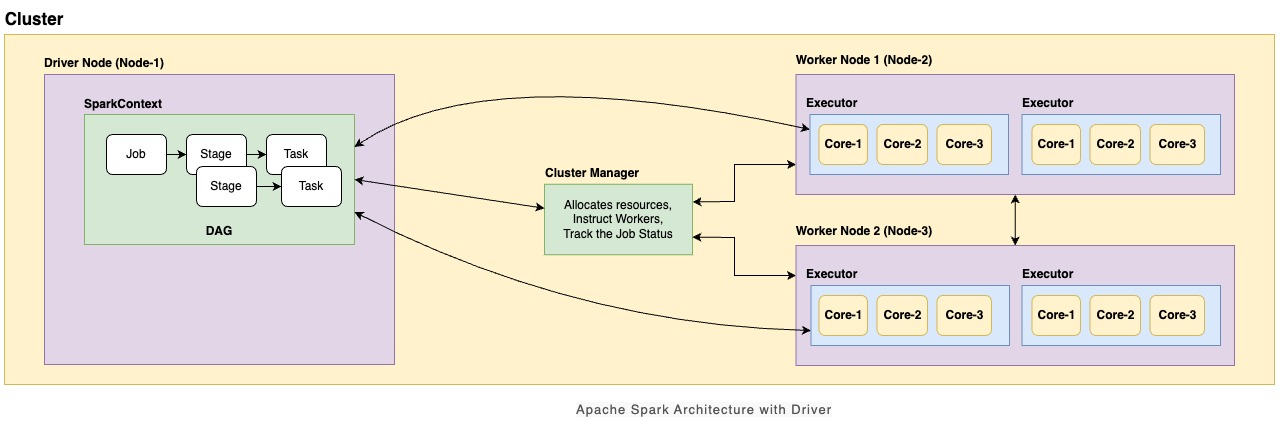

---

### 1.1 Spark Cluster Manager

**Purpose:** Allocates and manages resources across the cluster for distributed data processing.

**Types of Cluster Managers:**

1. **Standalone Scheduler** 
   - Built-in cluster manager that comes with Spark
   - Simple to set up, ideal for testing and small clusters
   - No external dependencies required

2. **Apache YARN (Yet Another Resource Negotiator)**
   - Most commonly used in Hadoop ecosystems
   - Two deployment modes: Client mode & Cluster mode
   - Better resource utilization with dynamic allocation

3. **Apache Mesos**
   - General-purpose cluster manager
   - Can run multiple frameworks (not just Spark)
   - Fine-grained resource sharing

4. **Kubernetes**
   - Modern container orchestration platform
   - Cloud-native deployment
   - Better for microservices architecture

**Key Responsibilities:**
- Resource allocation to applications
- Launching executors on worker nodes
- Monitoring resource usage
- Handling failures and rescheduling tasks

---

### 1.2 Spark Driver Program

The **Driver** is the brain of the Spark application that orchestrates the entire execution.

**Key Responsibilities:**

1. **Creates SparkContext/SparkSession:** 
   - Entry point for Spark functionality
   - Connects to the cluster manager
   
2. **Runs main() method:** 
   - Executes your application code
   - Parses the program logic

3. **Creates DAG (Directed Acyclic Graph):**
   - Represents logical execution plan
   - Optimizes the execution workflow
   
4. **Task Scheduling:**
   - Breaks jobs into stages and tasks
   - Assigns tasks to executors
   - Tracks task execution status

5. **Result Collection:**
   - Gathers results from executors
   - Returns final output to the user

**Driver Process Flow:**
```
Submit Application → Run main() → Create SparkContext → Build DAG → 
Request Resources → Schedule Tasks → Monitor Execution → Collect Results
```

---

### 1.3 Important Spark Concepts

#### **SparkContext**
- Connects to cluster manager to acquire executors
- Sends serialized code and data to workers
- Coordinates the execution of tasks
- **Note:** In Spark 2.0+, SparkSession is the unified entry point

#### **SparkSession**
- Unified entry point for DataFrame and Dataset APIs
- Encapsulates SparkContext, SQLContext, and HiveContext
- Provides a single point for all Spark operations

#### **RDD (Resilient Distributed Dataset)**
- Fundamental data structure of Spark
- Immutable, distributed collection of objects
- Fault-tolerant through lineage information
- Can be cached in memory for faster processing
- **Key Properties:**
  - **Resilient:** Fault-tolerant, can be recreated if lost
  - **Distributed:** Data split across multiple nodes
  - **Dataset:** Collection of partitioned data

#### **Directed Acyclic Graph (DAG)**
- Visual representation of the execution plan
- **Directed:** Data flows in one direction
- **Acyclic:** No circular dependencies
- **Graph:** Nodes (RDDs/DataFrames) and edges (transformations)
- Enables optimization before execution

**DAG Benefits:**
- Lazy evaluation optimization
- Pipeline optimization (combining operations)
- Fault tolerance through lineage
- Efficient task scheduling

---

### 1.4 Spark Executors (Workers)

**Executors** are the workhorses that perform the actual data processing.

**Key Characteristics:**

1. **Distributed Execution:**
   - Multiple executors run across worker nodes
   - Each executor is a separate JVM process
   
2. **Core-based Processing:**
   - Each executor has allocated CPU cores
   - Cores determine parallel task execution capacity
   - Example: 4 cores = 4 tasks running simultaneously

3. **Memory Management:**
   - Stores data in memory (caching/persistence)
   - Spills to disk when memory is full
   - Memory divided into: Execution + Storage + User + Reserved

4. **Task Execution:**
   - Receives serialized code from driver
   - Executes tasks on data partitions
   - Returns results/status back to driver

5. **Data I/O:**
   - Reads from multiple sources (HDFS, S3, databases, etc.)
   - Writes results to various destinations
   - Can read/write locally and remotely

**Executor Memory Layout:**
```
Total Executor Memory (100%)
├── Reserved Memory (~300MB) - System reserved
├── Spark Memory (60% by default)
│   ├── Storage Memory (50%) - Caching DataFrames/RDDs
│   └── Execution Memory (50%) - Shuffles, joins, sorts
└── User Memory (40%) - User data structures
```

**Example Configuration:**
```python
# Executor with 4 cores and 8GB memory
# Can run 4 tasks in parallel
# 4.8GB for Spark operations (caching + execution)
# 3.2GB for user code
```

### How Spark Job is created ?

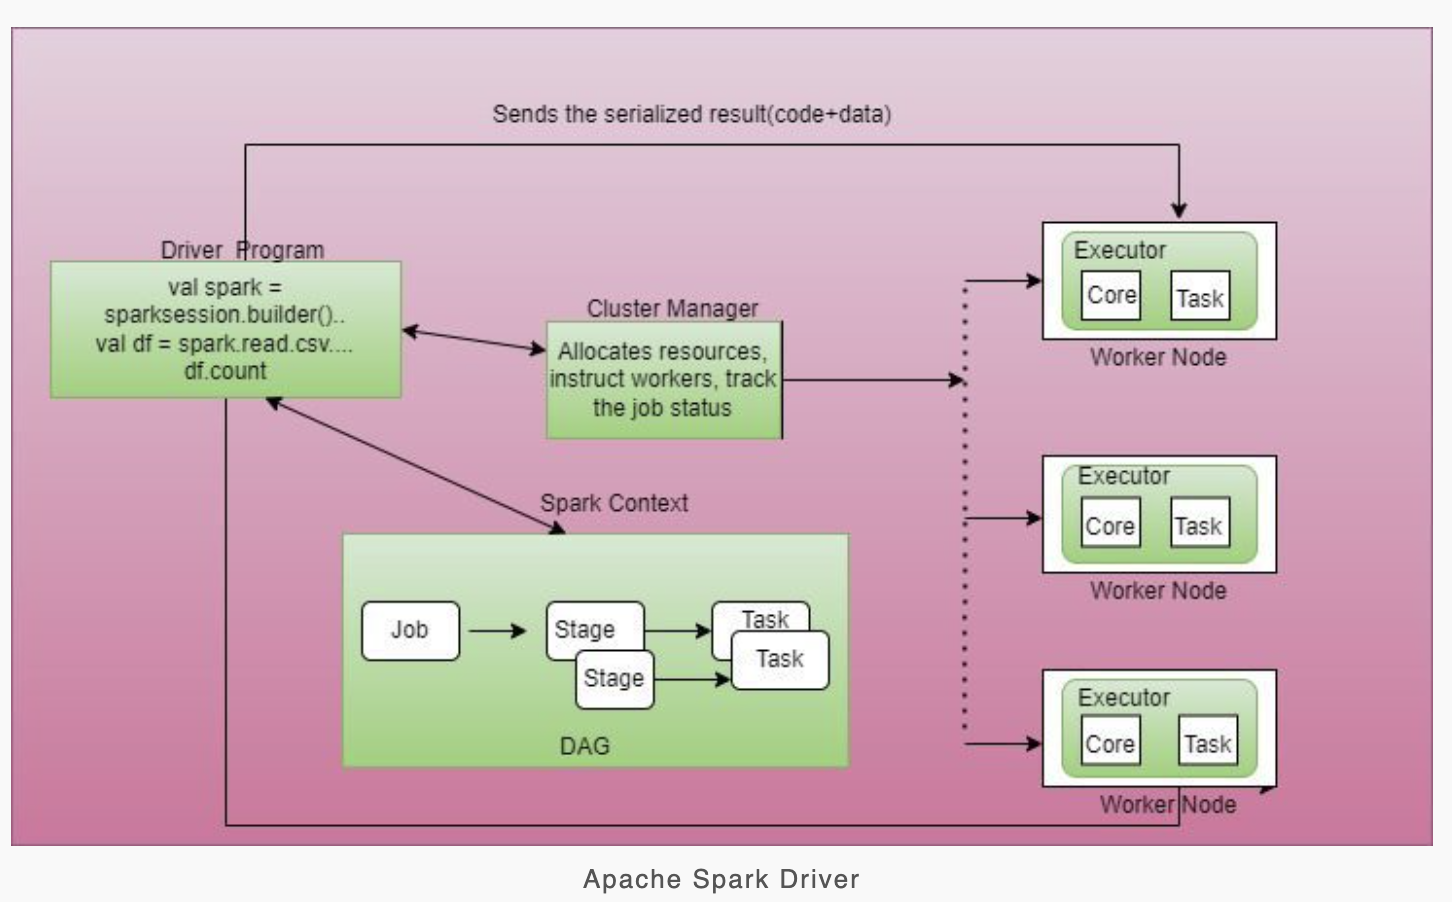

## 2. Spark Job Execution Flow - Detailed Steps

### Step-by-Step Execution Process:

**Step 1: Application Submission**
- User submits Spark application using `spark-submit` command
- Driver program is launched with specified configuration
- Driver JVM starts with allocated memory and cores

**Step 2: Driver Initialization**
- Driver runs the `main()` method of your application
- Creates `SparkContext` or `SparkSession` object
- Connects to the cluster manager
- Registers the application with the cluster

**Step 3: Code Parsing & DAG Creation**
- Driver parses your code (transformations and actions)
- **Lazy Evaluation:** Transformations are not executed immediately
- Builds RDD/DataFrame lineage (dependency graph)
- Creates DAG only when an **action** is called
- Multiple transformations are pipelined for optimization

**Step 4: Job Creation**
- When an action is triggered (`.collect()`, `.count()`, `.save()`), a **Job** is created
- Job is divided into **Stages** based on shuffle boundaries
- Each stage is divided into **Tasks** (one task per partition)

**Hierarchy:**
```
Job (triggered by action)
└── Stage 1 (narrow transformations)
    ├── Task 1 (Partition 1)
    ├── Task 2 (Partition 2)
    └── Task 3 (Partition 3)
└── Stage 2 (after shuffle - wide transformation)
    ├── Task 1 (Partition 1)
    └── Task 2 (Partition 2)
```

**Step 5: Resource Allocation**
- Driver requests executors from cluster manager
- Cluster manager allocates resources based on:
  - Number of executor instances requested
  - Memory per executor
  - Cores per executor
  - Available cluster resources

**Step 6: Task Scheduling & Distribution**
- **Task Scheduler** assigns tasks to executors
- Tasks are sent with:
  - Serialized code (closures/functions)
  - Partition metadata
  - Dependencies information
- Scheduling considers:
  - Data locality (PROCESS_LOCAL → NODE_LOCAL → RACK_LOCAL → ANY)
  - Executor availability
  - Task dependencies

**Step 7: Task Execution on Executors**
- Executors receive tasks from driver
- Execute the code on their assigned data partitions
- Perform computations in memory when possible
- Store intermediate results (for shuffle operations)
- Cache data if `.cache()` or `.persist()` was called

**Step 8: Result Collection**
- Executors send results back to driver (for actions like `.collect()`)
- Or write results to storage (for actions like `.save()`)
- Driver aggregates final results
- Updates task/stage/job status
- Returns output to user

---

### Key Execution Concepts:

#### **Transformations vs Actions**

**Transformations (Lazy):**
- Create new RDDs/DataFrames from existing ones
- Not executed until an action is called
- Examples: `map()`, `filter()`, `groupBy()`, `join()`
- Build up the DAG lineage

**Actions (Eager):**
- Trigger actual execution of the DAG
- Return results to driver or write to storage
- Examples: `collect()`, `count()`, `save()`, `show()`

#### **Narrow vs Wide Transformations**

**Narrow Transformations:**
- Each parent partition contributes to at most one child partition
- No shuffle required
- Can be pipelined together in same stage
- Examples: `map()`, `filter()`, `union()`
- Data locality preserved

**Wide Transformations:**
- Parent partitions contribute to multiple child partitions
- Requires shuffle (data exchange across nodes)
- Creates stage boundaries
- Examples: `groupByKey()`, `reduceByKey()`, `join()`
- More expensive due to network I/O

#### **Shuffle Operations**
- Data redistribution across partitions
- Involves disk I/O, network I/O, and serialization
- Most expensive operation in Spark
- Triggered by wide transformations
- Can be optimized using proper partitioning

---

### Practical Example:

```python
# This code execution flow
df = spark.read.csv("data.csv")           # Transformation (lazy)
df2 = df.filter(df['age'] > 25)           # Transformation (lazy)
df3 = df2.groupBy("city").count()         # Transformation (lazy)
result = df3.collect()                    # Action (triggers execution)

# What happens:
# 1. No execution until collect()
# 2. DAG is built with 3 transformations
# 3. collect() triggers job creation
# 4. Job split into stages (filter+read in Stage 1, groupBy in Stage 2)
# 5. Tasks created per partition
# 6. Executors process tasks
# 7. Results returned to driver
```

## 3. Spark Driver - Detailed Roles and Responsibilities

### Core Responsibilities:

1. **Application Entry Point**
   - Runs the `main()` method of your application
   - First process that starts when you submit a Spark job

2. **Creates SparkContext/SparkSession**
   - Establishes connection to cluster
   - Initializes Spark environment
   - Configures application settings

3. **DAG Construction & Optimization**
   - Converts your code into Task execution plan
   - Creates **Logical Plan** from transformations
   - Optimizes with **Catalyst Optimizer** (for DataFrames)
   - Generates **Physical Plan** for execution

4. **Plans Creation Hierarchy:**
   ```
   User Code
      ↓
   Logical Plan (what to compute)
      ↓
   Optimized Logical Plan (Catalyst Optimizer)
      ↓
   Physical Plans (how to compute - multiple strategies)
      ↓
   Selected Physical Plan (cost-based optimization)
      ↓
   RDDs + DAG (execution graph)
   ```

5. **Resource Management**
   - Negotiates with cluster manager for resources
   - Requests specific number of executors
   - Monitors executor health and availability
   - Handles dynamic allocation (add/remove executors)

6. **Task Scheduling**
   - Breaks jobs into stages based on shuffle boundaries
   - Divides stages into tasks (one per partition)
   - Assigns tasks to executors considering:
     - Data locality (prefer local data)
     - Executor availability
     - Speculative execution (retry slow tasks)

7. **Metadata Management**
   - Tracks which executor has which partition
   - Maintains RDD/DataFrame lineage information
   - Stores shuffle data locations
   - Monitors task completion status

8. **Coordination & Monitoring**
   - Coordinates work across all executors
   - Tracks execution progress
   - Handles task failures and retries
   - Monitors resource utilization

9. **Result Collection**
   - Aggregates results from executors
   - Returns final output to user
   - Handles result size limits (spark.driver.maxResultSize)

---

### Driver Deployment Modes:

#### **Client Mode** (Default)
- Driver runs on the client machine (where spark-submit is run)
- Good for interactive applications (notebooks, shells)
- **Pros:** Easy debugging, direct logs access
- **Cons:** Network latency to cluster, client must stay alive

#### **Cluster Mode**
- Driver runs inside the cluster (on a worker node)
- Good for production jobs
- **Pros:** Better for long-running jobs, less network overhead
- **Cons:** Harder to debug, logs are in cluster

---

### Key Driver Components:

#### **DAG Scheduler**
- Creates stages from job's DAG
- Submits stages to Task Scheduler
- Resubmits failed stages
- Determines preferred locations for tasks

#### **Task Scheduler**
- Schedules tasks on executors
- Manages task retries
- Implements locality-aware scheduling
- Handles speculative execution

#### **Block Manager Master**
- Tracks storage status across executors
- Manages cached RDD/DataFrame locations
- Coordinates data replication
- Handles eviction policies

#### **Broadcast Manager**
- Distributes broadcast variables efficiently
- Reduces data transfer by sending once per executor
- Manages broadcast lifecycle

---

### Important Driver Concepts:

**Speculative Execution:**
- Launches duplicate tasks for slow-running tasks
- Helps mitigate stragglers (slow tasks)
- Enabled by default: `spark.speculation = true`

**Data Locality Levels:**
1. **PROCESS_LOCAL:** Data in same JVM (cached data)
2. **NODE_LOCAL:** Data on same node (different JVM)
3. **RACK_LOCAL:** Data on same rack
4. **ANY:** Data anywhere in cluster

**Adaptive Query Execution (AQE):**
- Runtime optimization based on actual data statistics
- Dynamically adjusts:
  - Number of shuffle partitions
  - Join strategies
  - Skew handling

---

### Driver Monitoring & UI:

The Driver hosts **Spark Web UI** (default port 4040):
- **Jobs:** View all jobs and their stages
- **Stages:** See tasks, shuffle data, execution time
- **Storage:** Check cached RDDs/DataFrames
- **Environment:** Configuration and system properties
- **Executors:** Monitor executor status, memory, tasks
- **SQL:** Query plans and execution details

This comprehensive monitoring helps in:
- Performance tuning
- Debugging failures
- Understanding execution patterns
- Identifying bottlenecks

## 4. Spark Driver Configuration

The Driver is a JVM process that can be configured based on application requirements. Proper configuration is crucial for optimal performance.

---

### 4.1 Number of Driver Cores (`spark.driver.cores`)

**Purpose:** Determines the computational power available to the driver

**Key Points:**
- A **core** represents CPU computational power
- Controls parallel operations on the driver side
- **Only applicable in cluster mode**
- In client mode, uses the machine's available cores

**Default:** 1 core

**When to Increase:**
- Large broadcast variables need to be serialized
- Complex DAG creation and optimization
- Many concurrent jobs
- Result collection from many partitions

**Example:**

In [ ]:
from pyspark.sql import SparkSession

# Configure driver cores (only in cluster mode)
spark = SparkSession.builder \
    .master('local[*]') \
    .appName('Driver-Config-Example') \
    .config('spark.driver.cores', 4) \
    .getOrCreate()

# Example: Driver with 4 cores can handle more concurrent operations
print(f"Spark Version: {spark.version}")
print(f"App Name: {spark.sparkContext.appName}")

### 4.2 Driver Max Result Size (`spark.driver.maxResultSize`)

**Purpose:** Limits the maximum size of serialized results that can be collected to the driver

**Key Points:**
- Applies to actions like `.collect()`, `.take()`, `.toPandas()`
- Prevents driver from running out of memory
- Results larger than this limit will abort the job
- **Minimum:** 1MB
- **Default:** 1GB

**Important Considerations:**

1. **Memory Safety:**
   - Prevents OutOfMemoryError on driver
   - Critical for production stability
   
2. **When to Increase:**
   - Need to collect large results for analysis
   - Using `.toPandas()` on large DataFrames
   - Collecting aggregated results
   
3. **Best Practice:**
   - Avoid collecting large datasets to driver
   - Use `.write()` to save results instead
   - Sample data with `.limit()` before collecting
   - Filter/aggregate before collecting

**Warning Signs:**
```
org.apache.spark.SparkException: Job aborted due to stage failure: 
Total size of serialized results is bigger than spark.driver.maxResultSize
```

**Example:**

In [ ]:
from pyspark.sql import SparkSession

MAX_RESULT_SIZE = '5g'

spark = SparkSession.builder \
    .master('local[*]') \
    .appName('MaxResultSize-Config') \
    .config('spark.driver.maxResultSize', MAX_RESULT_SIZE) \
    .getOrCreate()

# Example: Safe data collection with limit
# BAD: df.collect()  # Can exceed maxResultSize
# GOOD: df.limit(1000).collect()  # Limited collection
# BETTER: df.write.parquet("output/")  # Write to storage

print(f"Max Result Size: {MAX_RESULT_SIZE}")
print("✓ Configure this based on your driver memory and use case")

### 4.3 Driver Memory (`spark.driver.memory`)

**Purpose:** Sets the amount of memory allocated to the driver JVM

**Key Points:**
- Controls total heap memory for driver operations
- Must be set BEFORE SparkSession creation
- Cannot be changed after application starts
- **Default:** 1GB (1g)

**Driver Memory Usage:**

1. **Storing Broadcast Variables**
   - Large lookup tables broadcast to executors
   - Cached on driver before distribution
   
2. **Collecting Results**
   - Results from `.collect()` stored in driver memory
   - Limited by `spark.driver.maxResultSize`
   
3. **Managing Metadata**
   - Partition locations and RDD lineage
   - Task scheduling information
   - Shuffle metadata
   
4. **Accumulator Updates**
   - Aggregated values from executors
   - Metrics and counters

**Sizing Guidelines:**

| Application Type | Driver Memory | Reasoning |
|-----------------|---------------|-----------|
| Simple ETL | 1-2 GB | Minimal metadata, no collections |
| Interactive Analysis | 4-8 GB | Frequent collections, notebooks |
| Complex Jobs | 8-16 GB | Large broadcasts, many partitions |
| Machine Learning | 16-32 GB | Model collection, feature caching |

**Formula:**
```
Driver Memory = Base (1GB) + Broadcast Size + Expected Result Size + Metadata Overhead
```

**Red Flags (Need More Driver Memory):**
- `java.lang.OutOfMemoryError: Java heap space` on driver
- Slow broadcast variable creation
- Jobs failing during result collection
- Driver GC (Garbage Collection) taking too long

**Best Practices:**
- Start conservative, increase if needed
- Monitor driver memory via Spark UI
- Use `.persist()` on executors, not driver
- Avoid large `.collect()` operations

**Example:**

In [ ]:
from pyspark.sql import SparkSession

DRIVER_MEMORY = '8g'

spark = SparkSession.builder \
    .master('local[*]') \
    .appName('Driver-Memory-Config') \
    .config('spark.driver.memory', DRIVER_MEMORY) \
    .getOrCreate()

# Example: Using broadcast variables (stored in driver memory first)
# Large lookup table - broadcasted to executors
lookup_data = [("CA", "California"), ("NY", "New York"), ("TX", "Texas")]
broadcast_var = spark.sparkContext.broadcast(dict(lookup_data))

print(f"Driver Memory: {DRIVER_MEMORY}")
print(f"Broadcast variable created: {type(broadcast_var)}")
print("✓ Ensure driver has enough memory for broadcasts and metadata")

# Clean up
broadcast_var.unpersist()

## 5. Spark Executor Configuration

Executors are the workhorses that perform actual data processing. Proper executor configuration is critical for performance and resource utilization.

---

### 5.1 Executor Memory (`spark.executor.memory`)

**Purpose:** Sets the heap memory allocated to each executor JVM

**Key Points:**
- Controls memory available for computation and storage
- **Default:** 1GB
- Divided into multiple regions (execution, storage, user, reserved)
- More memory ≠ always better (can cause GC issues)

**Memory Breakdown:**

```
Total Executor Memory (e.g., 8GB)
│
├── Reserved Memory (~300MB)
│   └── System overhead, internal metadata
│
├── Spark Memory (60% of usable = ~4.6GB)
│   ├── Storage Memory (50% = ~2.3GB)
│   │   └── Cached RDDs/DataFrames, broadcast variables
│   │
│   └── Execution Memory (50% = ~2.3GB)
│       └── Shuffles, joins, sorts, aggregations
│
└── User Memory (40% of usable = ~3.1GB)
    └── User data structures, UDFs, custom objects
```

**Controlled by:**
- `spark.memory.fraction` (default: 0.6) - Spark memory vs User memory
- `spark.memory.storageFraction` (default: 0.5) - Storage vs Execution

**Sizing Strategy:**

| Data Size | Executor Memory | Reasoning |
|-----------|-----------------|-----------|
| < 10 GB | 2-4 GB | Small datasets, minimal shuffles |
| 10-100 GB | 4-8 GB | Medium datasets, moderate shuffles |
| 100GB-1TB | 8-16 GB | Large datasets, heavy shuffles |
| > 1 TB | 16-32 GB | Very large, but watch GC overhead |

**Common Issues:**

1. **Too Small:**
   - Frequent spills to disk
   - Slow shuffle operations
   - OOM (OutOfMemoryError) exceptions
   
2. **Too Large (>64GB):**
   - Long GC pauses
   - Poor executor locality
   - Resource waste

**Best Practices:**
- Keep executor memory between 8-64 GB
- Monitor GC time (should be < 10% of task time)
- Increase partitions if facing memory issues
- Use off-heap memory for large datasets

---

### 5.2 Number of Executors (`spark.executor.instances`)

**Purpose:** Determines how many executor JVMs to launch

**Key Points:**
- More executors = more parallelism
- **Default:** 2 (in dynamic allocation, it varies)
- Trade-off between parallelism and resource utilization

**Calculation Formula:**
```
Total Executors = (Total Cluster Cores - Driver Cores) / Cores per Executor
```

**Example:**
```
Cluster: 10 nodes × 16 cores = 160 total cores
Driver: 4 cores
Cores per executor: 4

Executors = (160 - 4) / 4 = 39 executors
```

**Dynamic Allocation:**
- Automatically adds/removes executors based on workload
- Enabled: `spark.dynamicAllocation.enabled = true`
- Min executors: `spark.dynamicAllocation.minExecutors`
- Max executors: `spark.dynamicAllocation.maxExecutors`

---

### 5.3 Executor Cores (`spark.executor.cores`)

**Purpose:** Number of CPU cores allocated to each executor

**Key Points:**
- Each core can run one task concurrently
- **Default:** 1 in YARN, all available in standalone
- More cores = more parallel tasks per executor

**Optimal Values:**
- **2-5 cores** recommended for most workloads
- **4-5 cores** good balance between throughput and HDFS throughput
- Avoid > 5 cores (diminishing returns, GC issues)

**Task Parallelism:**
```
Total Parallel Tasks = Num Executors × Cores per Executor

Example:
10 executors × 4 cores = 40 tasks running in parallel
```

---

### 5.4 Executor Memory Overhead (`spark.executor.memoryOverhead`)

**Purpose:** Off-heap memory for JVM internals, native libraries, etc.

**Default:** 
```
max(executor.memory × 0.10, 384MB)
```

**When to Increase:**
- Using Python (PySpark) - Python process memory
- Native libraries (machine learning libraries)
- Large data serialization/deserialization
- Container killed with "Container killed by YARN for exceeding memory limits"

**Example:**
```
Executor memory: 16 GB
Memory overhead: 16 GB × 0.10 = 1.6 GB
Total container memory: 16 + 1.6 = 17.6 GB
```

---

### Complete Executor Configuration Example:

In [ ]:
from pyspark.sql import SparkSession

# Production-grade executor configuration
spark = SparkSession.builder \
    .master('local[*]') \
    .appName('Optimized-Executor-Config') \
    .config('spark.executor.memory', '16g') \
    .config('spark.executor.cores', 4) \
    .config('spark.executor.instances', 10) \
    .config('spark.executor.memoryOverhead', '2g') \
    .config('spark.memory.fraction', 0.6) \
    .config('spark.memory.storageFraction', 0.5) \
    .config('spark.dynamicAllocation.enabled', 'true') \
    .config('spark.dynamicAllocation.minExecutors', 2) \
    .config('spark.dynamicAllocation.maxExecutors', 20) \
    .config('spark.dynamicAllocation.initialExecutors', 10) \
    .getOrCreate()

# Calculate total parallelism
num_executors = 10  # Or use dynamic allocation
cores_per_executor = 4
total_parallel_tasks = num_executors * cores_per_executor

print("=" * 60)
print("EXECUTOR CONFIGURATION SUMMARY")
print("=" * 60)
print(f"Executor Memory (Heap): 16 GB")
print(f"Executor Memory Overhead (Off-heap): 2 GB")
print(f"Total Executor Container Memory: 18 GB")
print(f"Cores per Executor: {cores_per_executor}")
print(f"Number of Executors: {num_executors}")
print(f"Total Parallel Tasks: {total_parallel_tasks}")
print(f"Dynamic Allocation: Enabled (min=2, max=20)")
print("=" * 60)
print("\nMemory Distribution per Executor:")
print("  - Reserved Memory: ~300 MB")
print("  - Spark Memory (60%): ~9.4 GB")
print("    ├─ Storage Memory (50%): ~4.7 GB (caching)")
print("    └─ Execution Memory (50%): ~4.7 GB (shuffles/joins)")
print("  - User Memory (40%): ~6.3 GB (UDFs, custom objects)")
print("=" * 60)

## 6. Advanced Configuration & Optimization

### 6.1 Partitioning Strategy

**Partitions** are the fundamental unit of parallelism in Spark.

**Key Concepts:**
- Each partition is processed by a single task on a single core
- Optimal partitions = 2-4× the number of total cores in cluster
- Too few partitions → poor parallelism, large task data
- Too many partitions → overhead in task scheduling

**Default Partition Calculations:**
```python
# For reading files
partitions = number of input splits (HDFS block size based)

# For shuffles (joins, groupBy, etc.)
spark.sql.shuffle.partitions = 200 (default)

# For parallelize/RDD operations
spark.default.parallelism = num_executors × executor_cores
```

**Partition Sizing Guidelines:**
```
Ideal partition size: 100-200 MB
Max partition size: ~1 GB (to avoid OOM)

Formula:
Number of Partitions = Total Data Size / Target Partition Size

Example:
100 GB data / 128 MB = ~800 partitions
```

**Configuration:**

In [ ]:
# Partitioning Configuration Examples

# Calculate optimal shuffle partitions
num_executors = 10
cores_per_executor = 4
total_cores = num_executors * cores_per_executor
optimal_partitions = total_cores * 3  # 3x multiplier

spark.conf.set("spark.sql.shuffle.partitions", optimal_partitions)
spark.conf.set("spark.default.parallelism", total_cores * 2)

print(f"Total Cores: {total_cores}")
print(f"Optimal Shuffle Partitions: {optimal_partitions}")
print(f"Default Parallelism: {total_cores * 2}")

# Example: Manual repartitioning
from pyspark.sql import functions as F

# Create sample data
data = [(i, f"user_{i}", i * 100) for i in range(1, 1001)]
df = spark.createDataFrame(data, ["id", "name", "amount"])

print(f"\nOriginal partitions: {df.rdd.getNumPartitions()}")

# Repartition for better parallelism
df_repartitioned = df.repartition(optimal_partitions)
print(f"After repartition: {df_repartitioned.rdd.getNumPartitions()}")

# Coalesce (reduce partitions without shuffle - efficient)
df_coalesced = df_repartitioned.coalesce(10)
print(f"After coalesce: {df_coalesced.rdd.getNumPartitions()}")

# Partition by column (for skewed data)
df_partitioned_by_key = df.repartition(20, "id")
print(f"Partitioned by 'id' column: {df_partitioned_by_key.rdd.getNumPartitions()}")

### 6.2 Caching & Persistence

**Caching** stores data in memory/disk for reuse, avoiding recomputation.

**When to Cache:**
- DataFrame/RDD used multiple times
- Iterative algorithms (machine learning)
- Interactive analysis
- After expensive transformations (joins, aggregations)

**Storage Levels:**

| Level | Space Used | CPU Time | In Memory | On Disk | Serialized | Recompute |
|-------|------------|----------|-----------|---------|------------|-----------|
| MEMORY_ONLY | High | Low | Yes | No | No | On failure |
| MEMORY_AND_DISK | High | Medium | Yes | Yes (spill) | No | Rarely |
| MEMORY_ONLY_SER | Low | High | Yes | No | Yes | On failure |
| MEMORY_AND_DISK_SER | Low | High | Yes | Yes (spill) | Yes | Rarely |
| DISK_ONLY | Low | High | No | Yes | Yes | Rarely |
| OFF_HEAP | Medium | Low | Off-heap | No | Yes | On failure |

**Default:**
- DataFrame: `MEMORY_AND_DISK` (deserialized)
- RDD: `MEMORY_ONLY`

**Best Practices:**
1. Cache **after** filtering/transforming large datasets
2. **Unpersist** when no longer needed (free memory)
3. Use serialized storage for memory-constrained scenarios
4. Monitor storage in Spark UI

**Examples:**

In [ ]:
from pyspark import StorageLevel

# Create sample DataFrame
df = spark.range(1, 1000000).toDF("id")
df = df.withColumn("value", F.col("id") * 2)

# Different caching methods

# Method 1: Simple cache (MEMORY_AND_DISK)
df_cached = df.filter(F.col("id") > 5000).cache()
df_cached.count()  # Triggers caching
print("✓ Cached with default MEMORY_AND_DISK")

# Method 2: Persist with specific storage level
df_persisted = df.filter(F.col("id") < 5000).persist(StorageLevel.MEMORY_ONLY)
df_persisted.count()  # Triggers persistence
print("✓ Persisted with MEMORY_ONLY")

# Method 3: Serialized storage (saves memory)
df_serialized = df.filter(F.col("id") % 2 == 0).persist(StorageLevel.MEMORY_AND_DISK_SER)
df_serialized.count()
print("✓ Persisted with MEMORY_AND_DISK_SER (serialized)")

# Example: Reuse cached data (no recomputation)
print(f"\nFirst aggregation on cached data:")
print(f"Sum: {df_cached.agg(F.sum('value')).collect()[0][0]}")

print(f"\nSecond aggregation (uses cache, much faster):")
print(f"Avg: {df_cached.agg(F.avg('value')).collect()[0][0]}")

# Clean up - IMPORTANT!
df_cached.unpersist()
df_persisted.unpersist()
df_serialized.unpersist()
print("\n✓ All cached data unpersisted (memory freed)")

# Check if data is cached
print(f"\nIs df_cached still cached? {df_cached.is_cached}")

### 6.3 Broadcast Variables & Accumulators

#### **Broadcast Variables**

**Purpose:** Efficiently share large read-only data across all executors

**How it works:**
1. Data is sent once per executor (not per task)
2. Cached on each executor for reuse
3. Reduces network traffic significantly
4. Ideal for lookup tables, configuration data

**Use Cases:**
- Join large DataFrame with small lookup table
- Share machine learning models
- Distribute configuration/mapping data
- Filter based on large set of values

**Benefits:**
```
Without Broadcast: Data sent to each task
10 executors × 100 tasks × 100MB = 100GB network transfer

With Broadcast: Data sent once per executor
10 executors × 100MB = 1GB network transfer
```

---

#### **Accumulators**

**Purpose:** Aggregate values from executors back to driver (write-only for executors)

**Characteristics:**
- Only driver can read the value
- Executors can only add to it
- Fault-tolerant (guaranteed once semantics in actions)
- Lazy in transformations (may be counted multiple times)

**Use Cases:**
- Count specific events (errors, warnings)
- Track metrics (records processed, nulls found)
- Debug counters
- Custom monitoring

**Built-in Accumulator Types:**
- `LongAccumulator` - sum of long values
- `DoubleAccumulator` - sum of double values  
- `CollectionAccumulator` - collect values into list

**Important Notes:**
⚠️ Use accumulators only inside **actions** for guaranteed once semantics  
⚠️ In transformations, values may be counted multiple times due to retries

**Examples:**

In [ ]:
# ========== BROADCAST VARIABLES EXAMPLE ==========

# Scenario: Join transactions with country lookup table
transactions_data = [
    (1, "TX001", "US", 100),
    (2, "TX002", "UK", 200),
    (3, "TX003", "IN", 150),
    (4, "TX004", "US", 300),
    (5, "TX005", "IN", 250)
]

# Large lookup table (in practice, could be 100MB+)
country_lookup = {
    "US": "United States",
    "UK": "United Kingdom", 
    "IN": "India",
    "CA": "Canada",
    "AU": "Australia"
}

# Create DataFrame
df_transactions = spark.createDataFrame(
    transactions_data, 
    ["id", "transaction_id", "country_code", "amount"]
)

# Broadcast the lookup dictionary
broadcast_lookup = spark.sparkContext.broadcast(country_lookup)

print("✓ Broadcast variable created")
print(f"  Broadcast ID: {broadcast_lookup.id}")
print(f"  Lookup table size: {len(broadcast_lookup.value)} countries")

# Use broadcast in UDF
from pyspark.sql.types import StringType

@F.udf(returnType=StringType())
def get_country_name(code):
    # Access broadcast variable in executors
    return broadcast_lookup.value.get(code, "Unknown")

# Apply UDF using broadcast variable
df_enriched = df_transactions.withColumn(
    "country_name", 
    get_country_name(F.col("country_code"))
)

print("\n✓ Broadcasting saves network bandwidth:")
print("  Without broadcast: Lookup sent to each task")
print("  With broadcast: Lookup sent once per executor")

df_enriched.show()

# Clean up
broadcast_lookup.unpersist()
print("\n✓ Broadcast variable unpersisted")

print("\n" + "="*60)

# ========== ACCUMULATORS EXAMPLE ==========

# Create accumulators for tracking
error_count = spark.sparkContext.accumulator(0)
null_count = spark.sparkContext.accumulator(0)
processed_count = spark.sparkContext.accumulator(0)

# Sample data with some nulls and errors
data_with_issues = [
    (1, "Alice", 25, 5000),
    (2, "Bob", None, 6000),  # Null age
    (3, "Charlie", 30, None),  # Null salary
    (4, "David", 35, 7000),
    (5, "Eve", None, None),  # Multiple nulls
]

df_issues = spark.createDataFrame(
    data_with_issues, 
    ["id", "name", "age", "salary"]
)

# Function using accumulators
def process_with_tracking(row):
    processed_count.add(1)
    
    if row.age is None or row.salary is None:
        null_count.add(1)
    
    if row.age is not None and row.age < 0:
        error_count.add(1)
    
    return row

# Process data (use foreach for action - guaranteed once semantics)
df_issues.foreach(process_with_tracking)

print("\n" + "="*60)
print("ACCUMULATOR TRACKING RESULTS")
print("="*60)
print(f"Total records processed: {processed_count.value}")
print(f"Records with null values: {null_count.value}")
print(f"Records with errors: {error_count.value}")
print("="*60)

print("\n💡 Key Takeaway:")
print("   Broadcast: Driver → Executors (read-only, efficient distribution)")
print("   Accumulator: Executors → Driver (write-only, aggregation)")

## 7. Performance Optimization Checklist

### 7.1 Common Performance Issues & Solutions

| Issue | Symptom | Solution |
|-------|---------|----------|
| **Data Skew** | Few tasks take much longer | Repartition with salt, use AQE, broadcast joins |
| **Small Files** | Many small input files | Coalesce/repartition after read, compact files |
| **Large Shuffles** | Slow wide transformations | Broadcast smaller dataset, pre-aggregate |
| **OOM Errors** | OutOfMemoryError | Increase executor memory, reduce partition size |
| **Spill to Disk** | Slow execution, disk I/O | Increase memory, reduce data per partition |
| **GC Overhead** | High GC time (>10%) | Reduce executor memory, use serialized storage |
| **Stragglers** | Few slow tasks delay job | Enable speculation, fix data skew |
| **Too Many Partitions** | High task overhead | Reduce shuffle partitions, coalesce |
| **Too Few Partitions** | Poor parallelism | Increase partitions, repartition |

---

### 7.2 Optimization Best Practices

**Data Processing:**
1. ✅ Filter early, filter often (push down predicates)
2. ✅ Use columnar formats (Parquet, ORC) over row formats (CSV, JSON)
3. ✅ Partition data by commonly filtered columns
4. ✅ Broadcast small tables in joins (< 10 MB)
5. ✅ Use DataFrames over RDDs (Catalyst optimization)
6. ✅ Cache intermediate results used multiple times
7. ✅ Avoid UDFs when built-in functions available (UDFs skip Catalyst)

**Memory Management:**
1. ✅ Set appropriate executor memory (8-64 GB sweet spot)
2. ✅ Configure memory overhead for PySpark (10-20% of executor memory)
3. ✅ Use serialized caching for memory-constrained workloads
4. ✅ Monitor and tune garbage collection
5. ✅ Unpersist unused cached data

**Parallelism:**
1. ✅ Set optimal shuffle partitions (2-4× total cores)
2. ✅ Keep partition size 100-200 MB
3. ✅ Use 4-5 cores per executor (HDFS throughput sweet spot)
4. ✅ Enable dynamic allocation for variable workloads

**Shuffles:**
1. ✅ Minimize shuffles (use narrow transformations when possible)
2. ✅ Use `reduceByKey` over `groupByKey` (pre-aggregates)
3. ✅ Increase shuffle buffer size for large shuffles
4. ✅ Use appropriate join strategies (broadcast vs sort-merge)

**Code Optimization:**
1. ✅ Avoid `collect()` on large datasets
2. ✅ Use `df.write()` instead of `collect()`
3. ✅ Prefer built-in functions over UDFs
4. ✅ Use column pruning (select only needed columns)
5. ✅ Avoid `count()` unless necessary (use `isEmpty()` or `take(1)`)

---

### 7.3 Monitoring & Debugging

**Spark UI Tabs to Monitor:**

1. **Jobs Tab:**
   - Identify slow stages
   - Check task distribution
   - Find failed tasks

2. **Stages Tab:**
   - Task execution time
   - Shuffle read/write sizes
   - GC time percentage
   - Spill metrics (memory/disk)

3. **Storage Tab:**
   - Cached RDD/DataFrame sizes
   - Memory usage per executor
   - Evicted partitions

4. **Executors Tab:**
   - Executor resource utilization
   - Task failures per executor
   - Shuffle read/write per executor

5. **SQL Tab:**
   - Query execution plans
   - Physical plan details
   - AQE optimizations applied

**Key Metrics to Watch:**
- **GC Time:** Should be < 10% of task time
- **Shuffle Spill:** Minimize disk spills
- **Task Duration:** Look for stragglers (tasks taking 2x+ median time)
- **Data Skew:** Check task input size variance
- **Executor Memory:** Should not be 100% utilized constantly

---

### 7.4 Quick Performance Tuning Formula

```python
# Step 1: Calculate cluster resources
total_cores = num_nodes × cores_per_node
executor_cores = 5  # Sweet spot for HDFS

# Step 2: Calculate executors
num_executors = (total_cores - driver_cores) / executor_cores

# Step 3: Calculate executor memory
node_memory = RAM_per_node
executor_memory = (node_memory - 1GB) / (executors_per_node)

# Step 4: Set shuffle partitions
shuffle_partitions = num_executors × executor_cores × 2

# Step 5: Apply configuration
spark.conf.set("spark.executor.instances", num_executors)
spark.conf.set("spark.executor.cores", executor_cores)
spark.conf.set("spark.executor.memory", f"{executor_memory}g")
spark.conf.set("spark.sql.shuffle.partitions", shuffle_partitions)
```

**Example:**
```
Cluster: 10 nodes, 16 cores/node, 64GB RAM/node

Executors per node = 16 / 5 = 3
Total executors = 10 × 3 = 30
Executor memory = (64 - 1) / 3 = 21 GB
Shuffle partitions = 30 × 5 × 2 = 300
```

In [ ]:
# Complete Production Configuration Example

from pyspark.sql import SparkSession

# Cluster specifications
NUM_NODES = 10
CORES_PER_NODE = 16
RAM_PER_NODE = 64  # GB

# Calculate optimal configuration
DRIVER_CORES = 4
EXECUTOR_CORES = 5  # Sweet spot for HDFS throughput
EXECUTORS_PER_NODE = CORES_PER_NODE // EXECUTOR_CORES
TOTAL_EXECUTORS = NUM_NODES * EXECUTORS_PER_NODE
EXECUTOR_MEMORY = (RAM_PER_NODE - 1) // EXECUTORS_PER_NODE  # Leave 1GB for OS
MEMORY_OVERHEAD = int(EXECUTOR_MEMORY * 0.15)  # 15% for PySpark
SHUFFLE_PARTITIONS = TOTAL_EXECUTORS * EXECUTOR_CORES * 3

# Create optimized Spark session
spark = SparkSession.builder \
    .appName("Production-Optimized-Config") \
    .config("spark.master", "yarn") \
    .config("spark.submit.deployMode", "cluster") \
    \
    .config("spark.driver.cores", DRIVER_CORES) \
    .config("spark.driver.memory", "16g") \
    .config("spark.driver.maxResultSize", "4g") \
    \
    .config("spark.executor.instances", TOTAL_EXECUTORS) \
    .config("spark.executor.cores", EXECUTOR_CORES) \
    .config("spark.executor.memory", f"{EXECUTOR_MEMORY}g") \
    .config("spark.executor.memoryOverhead", f"{MEMORY_OVERHEAD}g") \
    \
    .config("spark.sql.shuffle.partitions", SHUFFLE_PARTITIONS) \
    .config("spark.default.parallelism", TOTAL_EXECUTORS * EXECUTOR_CORES) \
    \
    .config("spark.dynamicAllocation.enabled", "true") \
    .config("spark.dynamicAllocation.minExecutors", 5) \
    .config("spark.dynamicAllocation.maxExecutors", TOTAL_EXECUTORS) \
    .config("spark.dynamicAllocation.initialExecutors", TOTAL_EXECUTORS // 2) \
    \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.sql.adaptive.skewJoin.enabled", "true") \
    \
    .config("spark.speculation", "true") \
    .config("spark.speculation.multiplier", "2") \
    \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.sql.parquet.compression.codec", "snappy") \
    \
    .getOrCreate()

# Print configuration summary
print("=" * 70)
print("PRODUCTION SPARK CONFIGURATION")
print("=" * 70)
print(f"\n📊 CLUSTER SPECS:")
print(f"   Nodes: {NUM_NODES}")
print(f"   Cores per Node: {CORES_PER_NODE}")
print(f"   RAM per Node: {RAM_PER_NODE} GB")

print(f"\n🚗 DRIVER CONFIG:")
print(f"   Driver Cores: {DRIVER_CORES}")
print(f"   Driver Memory: 16 GB")
print(f"   Max Result Size: 4 GB")

print(f"\n⚙️  EXECUTOR CONFIG:")
print(f"   Total Executors: {TOTAL_EXECUTORS}")
print(f"   Executors per Node: {EXECUTORS_PER_NODE}")
print(f"   Cores per Executor: {EXECUTOR_CORES}")
print(f"   Memory per Executor: {EXECUTOR_MEMORY} GB")
print(f"   Memory Overhead: {MEMORY_OVERHEAD} GB")
print(f"   Total Container Memory: {EXECUTOR_MEMORY + MEMORY_OVERHEAD} GB")

print(f"\n🔄 PARALLELISM:")
print(f"   Total Cores: {TOTAL_EXECUTORS * EXECUTOR_CORES}")
print(f"   Shuffle Partitions: {SHUFFLE_PARTITIONS}")
print(f"   Default Parallelism: {TOTAL_EXECUTORS * EXECUTOR_CORES}")

print(f"\n📈 OPTIMIZATION:")
print(f"   Dynamic Allocation: Enabled (5-{TOTAL_EXECUTORS})")
print(f"   Adaptive Query Execution: Enabled")
print(f"   Speculative Execution: Enabled")
print(f"   Skew Join Optimization: Enabled")
print(f"   Serializer: Kryo")
print(f"   Compression: Snappy")

print("=" * 70)

# Performance calculation
total_memory = TOTAL_EXECUTORS * (EXECUTOR_MEMORY + MEMORY_OVERHEAD)
total_cores = TOTAL_EXECUTORS * EXECUTOR_CORES
print(f"\n💪 CLUSTER POWER:")
print(f"   Total Memory: {total_memory} GB")
print(f"   Total CPU Cores: {total_cores}")
print(f"   Max Parallel Tasks: {total_cores}")
print("=" * 70)

## 8. Quick Revision Summary

### 🎯 Key Architecture Components

| Component | Role | Key Points |
|-----------|------|------------|
| **Driver** | Master/Brain | Runs main(), creates DAG, schedules tasks, collects results |
| **Cluster Manager** | Resource Manager | Allocates executors (YARN, Mesos, K8s, Standalone) |
| **Executors** | Workers | Execute tasks, store data, run in parallel |
| **SparkContext/Session** | Entry Point | Connects to cluster, unified API (2.0+) |

---

### 📊 Execution Flow (Remember)

```
1. Submit Application → Driver starts
2. Driver runs main() → Creates SparkContext/SparkSession
3. Parse code → Build DAG (lazy evaluation)
4. Action triggered → Create Job → Divide into Stages → Create Tasks
5. Request resources → Cluster Manager allocates Executors
6. Schedule tasks → Send to Executors (with code + data)
7. Executors run tasks → Return results to Driver
8. Driver aggregates → Return to user
```

---

### 🔑 Critical Concepts

**DAG (Directed Acyclic Graph):**
- Visual execution plan
- Optimized before execution
- Stages separated by shuffles

**Transformations (Lazy):**
- Narrow: `map`, `filter`, `union` (no shuffle)
- Wide: `groupBy`, `join`, `reduceByKey` (shuffle)

**Actions (Eager):**
- Trigger execution: `collect`, `count`, `save`, `show`

**RDD Properties:**
- **R**esilient: Fault-tolerant via lineage
- **D**istributed: Across partitions
- **D**ataset: Immutable collection

---

### ⚙️ Configuration Quick Reference

**Driver:**
```python
spark.driver.cores = 4                    # CPU cores (cluster mode)
spark.driver.memory = "8g"                # Heap memory
spark.driver.maxResultSize = "4g"         # Max collect() size
```

**Executor:**
```python
spark.executor.instances = 30             # Number of executors
spark.executor.cores = 5                  # Cores per executor (4-5 ideal)
spark.executor.memory = "16g"             # Heap memory (8-64GB range)
spark.executor.memoryOverhead = "2g"      # Off-heap (10-15% for PySpark)
```

**Partitioning:**
```python
spark.sql.shuffle.partitions = 200        # Shuffle operations (set to cores × 2-4)
spark.default.parallelism = 100           # RDD operations
```

**Optimization:**
```python
spark.dynamicAllocation.enabled = true    # Auto scale executors
spark.sql.adaptive.enabled = true         # Runtime optimization (AQE)
spark.speculation = true                  # Handle stragglers
```

---

### 💾 Memory Distribution (Executor)

```
Total Executor Memory (e.g., 16GB)
├── Reserved: ~300MB
├── Spark Memory (60%): ~9.6GB
│   ├── Storage (50%): ~4.8GB → Caching/persistence
│   └── Execution (50%): ~4.8GB → Shuffles/joins
└── User Memory (40%): ~6.4GB → UDFs, custom objects
```

---

### 🚀 Performance Formula

```python
# Optimal Configuration
executor_cores = 5
num_executors = (total_cores - driver_cores) / executor_cores
executor_memory = (node_ram - 1GB) / executors_per_node
shuffle_partitions = num_executors × executor_cores × 2-4

# Partition sizing
partitions = data_size_gb / 0.128  # 128MB per partition
```

---

### 🎓 Must Remember

1. **Lazy Evaluation**: Transformations build DAG, actions execute
2. **Shuffle = Expensive**: Wide transformations trigger shuffles
3. **Broadcast for Small Data**: Avoid shuffle for small joins (<10MB)
4. **Cache Wisely**: Only cache data used multiple times
5. **Partition Size**: 100-200MB ideal, max 1GB
6. **Executor Cores**: 4-5 sweet spot for HDFS
7. **Avoid collect()**: On large datasets (use write instead)
8. **DataFrame > RDD**: Catalyst optimizer benefits
9. **Monitor Spark UI**: Key to debugging and tuning
10. **GC Time < 10%**: Of total task time

---

### 📝 Common Interview Questions

1. **Difference between Driver and Executor?**
   - Driver: Orchestrates, schedules, collects results
   - Executor: Executes tasks, stores data

2. **Narrow vs Wide transformations?**
   - Narrow: No shuffle (map, filter)
   - Wide: Shuffle required (groupBy, join)

3. **How does Spark achieve fault tolerance?**
   - RDD lineage (DAG) - can recreate lost partitions
   - Data replication
   - Task retry mechanism

4. **When to use cache vs persist?**
   - cache(): Default MEMORY_AND_DISK
   - persist(): Custom storage level

5. **How to optimize joins?**
   - Broadcast small tables
   - Partition by join key
   - Enable AQE for skew handling

---

### ✅ Pre-Execution Checklist

- [ ] Set appropriate executor memory and cores
- [ ] Configure shuffle partitions based on cluster size
- [ ] Enable dynamic allocation for variable workloads
- [ ] Turn on AQE (Adaptive Query Execution)
- [ ] Use Parquet/ORC format for better performance
- [ ] Partition data by commonly filtered columns
- [ ] Broadcast small lookup tables
- [ ] Cache intermediate results used multiple times
- [ ] Monitor Spark UI for bottlenecks
- [ ] Check for data skew in stages

## 9. Serialization & Deserialization in Spark

### 🔄 What is Serialization?

**Serialization** is the process of converting data structures or objects into a format (byte stream) that can be:
- Stored in memory/disk
- Transmitted over a network
- Reconstructed later

**Think of it as:** Converting complex objects into a "flat" byte format for transfer/storage.

```
Object/Data Structure  →  [Serialization]  →  Byte Stream
(In Memory - Complex)                          (Flat - Transferable)
```

---

### 🔄 What is Deserialization?

**Deserialization** is the reverse process - converting the byte stream back into the original object/data structure.

```
Byte Stream  →  [Deserialization]  →  Object/Data Structure
(Flat bytes)                           (Usable in Memory)
```

---

### 🤔 Why Does Spark Need Serialization?

#### 1. **Network Transfer (Driver ↔ Executors)**
When the Driver sends tasks to Executors:
- Your Python/Scala code (functions, closures)
- Data to be processed
- Configuration objects

**Flow:**
```
Driver: Serialize task → Network transfer → Executor: Deserialize task → Execute
```

#### 2. **Storage & Caching**
When caching/persisting DataFrames:
- **Deserialized storage** (MEMORY_ONLY): Objects stored as-is in JVM heap
- **Serialized storage** (MEMORY_ONLY_SER): Objects converted to compact bytes

#### 3. **Shuffle Operations**
During shuffles (groupBy, join):
- Data written to disk/network in serialized format
- Transferred across executors
- Deserialized on receiving executor

#### 4. **Checkpointing**
When saving RDD lineage to disk:
- Entire RDD state serialized to persistent storage
- Can be recovered after failures

---

### 📊 Serialization in Action - Visual Flow

```
USER CODE:
df.filter(lambda x: x > 10).map(custom_function)

DRIVER:
1. Parse user code
2. SERIALIZE: custom_function → bytes
3. SERIALIZE: task metadata → bytes
4. Send to Executor

NETWORK:
Byte stream transmitted...

EXECUTOR:
1. Receive byte stream
2. DESERIALIZE: bytes → custom_function
3. DESERIALIZE: bytes → task metadata
4. Execute function on partition
5. SERIALIZE: results → bytes
6. Send back to Driver

DRIVER:
1. Receive results (bytes)
2. DESERIALIZE: bytes → results
3. Show to user
```

---

### 🔑 Serialized vs Deserialized Storage

| Aspect | Deserialized | Serialized |
|--------|--------------|------------|
| **Format** | Java/Python objects | Byte arrays |
| **Memory Usage** | High (full objects) | Low (compact bytes) |
| **Access Speed** | Fast (direct access) | Slower (deserialize first) |
| **GC Overhead** | High (many objects) | Low (fewer objects) |
| **CPU Usage** | Lower | Higher (ser/deser cost) |
| **Use Case** | Frequent access | Memory-constrained |

**Memory Comparison Example:**
```
DataFrame with 1M rows:
- Deserialized (MEMORY_ONLY): ~500 MB
- Serialized (MEMORY_ONLY_SER): ~150 MB

Savings: 70% less memory!
```

---

### 🛠️ Serialization Formats in Spark

#### 1. **Java Serialization** (Default - Not Recommended)
```python
spark.serializer = "org.apache.spark.serializer.JavaSerializer"
```

**Characteristics:**
- ✗ Slow (verbose format)
- ✗ Large serialized size
- ✓ Can serialize almost any Java object
- ✗ Poor performance

#### 2. **Kryo Serialization** (Recommended - Production)
```python
spark.serializer = "org.apache.spark.serializer.KryoSerializer"
```

**Characteristics:**
- ✓ **10x faster** than Java serialization
- ✓ **Compact** - smaller byte size
- ✓ Better for shuffle operations
- ✗ Requires class registration for custom types (optional)
- ✓ Default for shuffle serialization in Spark 2.0+

**Performance Impact:**
```
Shuffle operation on 100GB data:
- Java Serializer: 45 minutes
- Kryo Serializer: 5 minutes

Network transfer:
- Java: ~100GB
- Kryo: ~30GB
```

---

### 📝 Storage Levels - Serialization Impact

| Storage Level | Serialized? | Memory | Disk | Description |
|--------------|-------------|--------|------|-------------|
| MEMORY_ONLY | ❌ No | ✓ | ✗ | Fast access, high memory |
| MEMORY_ONLY_SER | ✓ Yes | ✓ | ✗ | Compact, slower access |
| MEMORY_AND_DISK | ❌ No | ✓ | ✓ | Spills to disk if needed |
| MEMORY_AND_DISK_SER | ✓ Yes | ✓ | ✓ | Compact, spills to disk |
| DISK_ONLY | ✓ Yes | ✗ | ✓ | Slowest, minimal memory |
| OFF_HEAP | ✓ Yes | Off-heap | ✗ | Outside JVM, no GC |

---

### 🎯 When to Use Serialized Storage?

**✅ Use SERIALIZED Storage When:**
- Memory is limited (need to cache more data)
- GC pauses are causing issues
- Long-term caching (hours/days)
- Large datasets that don't fit in memory
- Network-intensive shuffle operations

**✅ Use DESERIALIZED Storage When:**
- Memory is abundant
- Speed is critical (frequent access)
- Short-term caching
- Small to medium datasets
- Interactive analysis (notebooks)

---

### 💡 Real-World Analogy

**Serialization = Packing for a trip**

**Serialization (Packing):**
- Clothes (objects) → Compressed in suitcase (bytes)
- Easy to transport
- Takes time to pack
- Saves space

**Deserialization (Unpacking):**
- Suitcase (bytes) → Wearable clothes (objects)
- Ready to use immediately
- Takes time to unpack
- Needs space

**In Spark:**
1. Driver packs (serializes) tasks → sends to executors
2. Executors unpack (deserialize) → execute
3. Results packed (serialized) → sent back to driver
4. Driver unpacks (deserializes) → shows results

---

### 🚀 Best Practices

1. **Always use Kryo serialization in production:**
   ```python
   .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
   ```

2. **Use serialized caching for large datasets:**
   ```python
   df.persist(StorageLevel.MEMORY_AND_DISK_SER)
   ```

3. **Register custom classes with Kryo (for complex objects):**
   ```python
   .config("spark.kryo.registrationRequired", "false")
   .config("spark.kryo.classesToRegister", "com.example.MyClass")
   ```

4. **Monitor serialization overhead in Spark UI:**
   - Check "Shuffle Write Time"
   - Look for serialization in task metrics

5. **Avoid serializing large objects in closures:**
   ```python
   # BAD: large_dict is serialized with every task
   large_dict = {...}  # 100MB
   rdd.map(lambda x: large_dict.get(x))
   
   # GOOD: Use broadcast variable
   broadcast_dict = spark.sparkContext.broadcast(large_dict)
   rdd.map(lambda x: broadcast_dict.value.get(x))
   ```

---

### ⚠️ Common Serialization Issues

**1. NotSerializableException:**
```python
# Problem: Object cannot be serialized
class MyClass:
    def __init__(self):
        self.file = open("data.txt")  # File objects can't be serialized!

# Solution: Only serialize what's needed
class MyClass:
    def __init__(self):
        self.filename = "data.txt"
    
    def process(self):
        with open(self.filename) as f:  # Open on executor
            return f.read()
```

**2. Large Closure Serialization:**
```python
# Problem: Entire class instance serialized
class DataProcessor:
    def __init__(self):
        self.large_data = [...]  # 1GB
    
    def process(self, rdd):
        return rdd.map(lambda x: x + len(self.large_data))  # Serializes entire object!

# Solution: Extract only needed values
class DataProcessor:
    def __init__(self):
        self.large_data = [...]
    
    def process(self, rdd):
        data_size = len(self.large_data)  # Extract value
        return rdd.map(lambda x: x + data_size)  # Only serializes data_size
```

**3. Task Size Too Large:**
```
ERROR: Task serialized size (1024 MB) exceeds spark.rpc.message.maxSize (128 MB)

Solution:
- Use broadcast variables
- Reduce closure size
- Increase spark.rpc.message.maxSize (not recommended)
```

In [ ]:
# ========== SERIALIZATION BASICS - Python Example ==========

import pickle  # Python's built-in serialization library
import sys

print("="*70)
print("SERIALIZATION & DESERIALIZATION DEMO")
print("="*70)

# Original Python object (in memory)
person = {
    'name': 'Alice',
    'age': 30,
    'skills': ['Python', 'Spark', 'SQL'],
    'salary': 95000
}

print("\n1️⃣ ORIGINAL OBJECT (In Memory):")
print(f"   Data: {person}")
print(f"   Type: {type(person)}")
print(f"   Memory size: ~{sys.getsizeof(person)} bytes")

# ===== SERIALIZATION: Object → Bytes =====
serialized_data = pickle.dumps(person)  # dumps = dump to string (bytes)

print("\n2️⃣ SERIALIZED (Byte Stream):")
print(f"   Bytes: {serialized_data[:50]}...")  # Show first 50 bytes
print(f"   Type: {type(serialized_data)}")
print(f"   Size: {len(serialized_data)} bytes")
print(f"   ✓ This can be sent over network or saved to disk")

# ===== DESERIALIZATION: Bytes → Object =====
deserialized_person = pickle.loads(serialized_data)  # loads = load from string

print("\n3️⃣ DESERIALIZED (Back to Object):")
print(f"   Data: {deserialized_person}")
print(f"   Type: {type(deserialized_person)}")
print(f"   Equal to original? {person == deserialized_person}")
print(f"   ✓ Object fully restored from bytes!")

print("\n" + "="*70)

# ===== SIMULATING NETWORK TRANSFER =====
print("\n📡 SIMULATING DRIVER → EXECUTOR TRANSFER:")
print("-" * 70)

# Driver side: Prepare function to send
def calculate_bonus(salary):
    return salary * 0.10

print("Driver: Original function defined")
print(f"        Function: {calculate_bonus}")
print(f"        Test: calculate_bonus(50000) = {calculate_bonus(50000)}")

# Serialize function (what Driver does)
serialized_function = pickle.dumps(calculate_bonus)
print(f"\nDriver: Function serialized → {len(serialized_function)} bytes")
print(f"        Ready to send over network...")

# Network transfer happens here (simulated)
print("\n🌐 Network: Transferring bytes...")

# Executor side: Receive and deserialize
received_function = pickle.loads(serialized_function)
print(f"\nExecutor: Function deserialized")
print(f"          Executing on partition data...")
result = received_function(75000)
print(f"          Result: {result}")

print("\n✅ Complete cycle: Driver → Serialize → Network → Deserialize → Execute")
print("="*70)

In [ ]:
# ========== SPARK SERIALIZATION EXAMPLES ==========

from pyspark.sql import SparkSession
from pyspark import StorageLevel
from pyspark.sql import functions as F
import time

# Create Spark session with Kryo serializer
spark = SparkSession.builder \
    .appName("Serialization-Examples") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .getOrCreate()

print("="*70)
print("SPARK SERIALIZATION IN ACTION")
print("="*70)

# ===== EXAMPLE 1: STORAGE LEVEL COMPARISON =====
print("\n📦 EXAMPLE 1: Deserialized vs Serialized Storage")
print("-"*70)

# Create sample DataFrame
df = spark.range(1, 500000).toDF("id")
df = df.withColumn("value", F.col("id") * 2)
df = df.withColumn("square", F.col("id") * F.col("id"))

# Cache as DESERIALIZED (default)
df_deserialized = df.cache()
count1 = df_deserialized.count()  # Trigger caching

print("\n✓ DESERIALIZED Storage (MEMORY_AND_DISK):")
print("  - Stored as Java objects in JVM heap")
print("  - Faster access (no deserialization)")
print("  - Uses MORE memory")
print("  - Higher GC overhead")

# Cache as SERIALIZED
df_serialized = df.persist(StorageLevel.MEMORY_AND_DISK_SER)
count2 = df_serialized.count()  # Trigger caching

print("\n✓ SERIALIZED Storage (MEMORY_AND_DISK_SER):")
print("  - Stored as compact byte arrays")
print("  - Slower access (must deserialize)")
print("  - Uses LESS memory (~70% reduction)")
print("  - Lower GC overhead")

print("\n💡 Use Case:")
print("   Deserialized → Frequently accessed data, plenty of memory")
print("   Serialized → Large datasets, memory-constrained environments")

# Cleanup
df_deserialized.unpersist()
df_serialized.unpersist()

# ===== EXAMPLE 2: KRYO vs JAVA SERIALIZATION =====
print("\n\n🚀 EXAMPLE 2: Kryo Serialization (Configured)")
print("-"*70)

print("\n✓ Current Spark Configuration:")
print(f"  Serializer: {spark.conf.get('spark.serializer')}")
print("\n  Benefits of Kryo:")
print("    • 10x faster than Java serialization")
print("    • Smaller serialized size (~3x smaller)")
print("    • Better for shuffle operations")
print("    • Reduced network traffic")

# ===== EXAMPLE 3: TASK SERIALIZATION =====
print("\n\n📤 EXAMPLE 3: Function Serialization in Tasks")
print("-"*70)

# Create RDD
rdd = spark.sparkContext.parallelize(range(1, 11), numSlices=3)

# Define function (will be serialized)
def complex_calculation(x):
    """This function will be serialized and sent to executors"""
    return (x ** 2) + (x * 10) + 5

print("\nDriver: Function 'complex_calculation' defined")
print("        This function will be:")
print("        1. Serialized by Driver")
print("        2. Sent to all Executors over network")
print("        3. Deserialized on each Executor")
print("        4. Executed on partitions")

# Apply transformation (function gets serialized here)
result_rdd = rdd.map(complex_calculation)

# Action triggers execution
results = result_rdd.collect()

print(f"\nResults: {results}")
print("\n✓ Complete flow executed successfully!")

# ===== EXAMPLE 4: CLOSURE SERIALIZATION PITFALL =====
print("\n\n⚠️  EXAMPLE 4: Closure Serialization (Common Pitfall)")
print("-"*70)

# BAD PRACTICE: Large object in closure
large_lookup = {i: i*100 for i in range(1, 10001)}  # 10k entries

print("\n❌ BAD: Large object serialized with every task")
print(f"   Lookup table size: {len(large_lookup)} entries")
print("   Problem: Entire lookup dict serialized for each task")
print("   Impact: High network traffic, slow performance")

# GOOD PRACTICE: Use broadcast variable
broadcast_lookup = spark.sparkContext.broadcast(large_lookup)

print("\n✅ GOOD: Use Broadcast Variable")
print(f"   Broadcast ID: {broadcast_lookup.id}")
print("   Benefit: Sent ONCE per executor (not per task)")
print("   Savings: 100x less network traffic for 100 tasks")

# Using broadcast
rdd_small = spark.sparkContext.parallelize([1, 2, 3, 4, 5])
result_broadcast = rdd_small.map(lambda x: broadcast_lookup.value.get(x, 0)).collect()
print(f"\n   Results using broadcast: {result_broadcast}")

# Cleanup
broadcast_lookup.unpersist()

# ===== EXAMPLE 5: SHUFFLE SERIALIZATION =====
print("\n\n🔀 EXAMPLE 5: Shuffle Operation (Heavy Serialization)")
print("-"*70)

df_shuffle = spark.range(1, 100000).toDF("id")
df_shuffle = df_shuffle.withColumn("category", F.col("id") % 10)

print("\nPerforming groupBy (triggers shuffle)...")
print("  During shuffle:")
print("  1. Data SERIALIZED on source executor")
print("  2. Written to disk/network")
print("  3. Transferred to destination executor")
print("  4. DESERIALIZED on destination")
print("  5. Aggregation performed")

grouped = df_shuffle.groupBy("category").count()
result_count = grouped.count()

print(f"\n✓ Shuffle completed: {result_count} groups")
print("\n💡 Kryo serialization makes shuffles much faster!")

print("\n" + "="*70)
print("KEY TAKEAWAYS:")
print("="*70)
print("1. Serialization converts objects → bytes for transfer/storage")
print("2. Deserialization converts bytes → objects for processing")
print("3. Use Kryo serializer for better performance")
print("4. Use serialized caching for large datasets")
print("5. Use broadcast variables to avoid repeated serialization")
print("6. Shuffles involve heavy serialization/deserialization")
print("="*70)

## 10. RDDs vs DataFrames vs Datasets - Complete Comparison

### 🎯 Overview: Three Data Abstractions in Spark

Spark provides three main data structures for distributed computing, each with different trade-offs:

1. **RDD (Resilient Distributed Dataset)** - Low-level, functional programming
2. **DataFrame** - High-level, SQL-like operations, schema-aware
3. **Dataset** - Type-safe DataFrames (Scala/Java only, not in PySpark)

---

### 📊 Quick Comparison Table

| Feature | RDD | DataFrame | Dataset |
|---------|-----|-----------|---------|
| **Type Safety** | ❌ No (runtime errors) | ❌ No (runtime errors) | ✅ Yes (compile-time errors) |
| **Schema** | ❌ No schema | ✅ Schema enforced | ✅ Schema + type safety |
| **Optimization** | ❌ No optimization | ✅ Catalyst optimizer | ✅ Catalyst optimizer |
| **Performance** | Slower | Fast | Fast |
| **API Style** | Functional (map, filter) | SQL-like (select, where) | Both |
| **Language** | All (Python, Scala, Java) | All | Scala/Java only |
| **Serialization** | Java/Kryo | Tungsten (optimized) | Tungsten (optimized) |
| **Memory Usage** | High | Low (columnar) | Low (columnar) |
| **Ease of Use** | Complex | Easy (SQL-like) | Medium |
| **When to Use** | Complex logic, unstructured | Structured data, SQL ops | Type safety needed (Scala) |

---

### 🔍 Detailed Breakdown

### 1. RDD (Resilient Distributed Dataset)

**What is it?**
- Foundational data structure of Spark (available since Spark 1.0)
- Immutable, distributed collection of objects
- Low-level API with functional transformations
- No schema or structure awareness

**Characteristics:**

✅ **Pros:**
- Full control over data processing
- Flexible - works with any data type
- Complex transformations possible
- Works with unstructured data
- Fine-grained control over partitions

❌ **Cons:**
- No automatic optimization
- No schema (can't leverage Catalyst optimizer)
- Higher memory usage (object overhead)
- Slower than DataFrames
- More verbose code
- No built-in SQL support

**When to Use RDD:**
- Processing unstructured data (text files, binary data)
- Need low-level transformations not available in DataFrame API
- Working with non-tabular data
- Need precise control over partitioning/execution
- Legacy code maintenance

**Performance:**
```
Processing 100GB data:
RDD: 45 minutes
DataFrame: 5 minutes
(9x slower due to no optimization)
```

---

### 2. DataFrame

**What is it?**
- Distributed collection organized into named columns (like a table)
- Built on top of RDDs with schema
- High-level API similar to SQL and Pandas
- Available in all languages (Python, Scala, Java, R)

**Characteristics:**

✅ **Pros:**
- **Catalyst Optimizer** - automatic query optimization
- **Tungsten Execution Engine** - optimized memory/CPU usage
- SQL support (can run SQL queries directly)
- Columnar storage (better compression)
- Much faster than RDDs
- Easy to use (SQL-like syntax)
- Language-agnostic (same API across languages)
- Built-in functions for common operations

❌ **Cons:**
- No compile-time type safety (runtime errors only)
- Less flexible than RDDs for complex logic
- Row-based operations can be slow
- Schema must be defined or inferred

**When to Use DataFrame:**
- **Default choice for most use cases**
- Structured/semi-structured data (CSV, JSON, Parquet)
- SQL-like operations (filter, join, aggregate)
- Performance is critical
- Working with PySpark (Datasets not available)

**Performance Benefits:**
```
Catalyst Optimizer:
- Predicate pushdown
- Projection pruning  
- Constant folding
- Join reordering

Tungsten Engine:
- Off-heap memory management
- Cache-aware computation
- Code generation (WholeStageCodegen)
```

---

### 3. Dataset

**What is it?**
- Type-safe version of DataFrames
- Combines benefits of RDDs (type safety) and DataFrames (optimization)
- **Only available in Scala and Java** (not in PySpark)
- Essentially: DataFrame = Dataset[Row] in Scala

**Characteristics:**

✅ **Pros:**
- **Compile-time type safety** (catch errors before runtime)
- Catalyst optimizer benefits (like DataFrames)
- Functional transformations with type safety
- Best of both RDDs and DataFrames
- Encoder-based serialization (faster than Java/Kryo)

❌ **Cons:**
- Only Scala/Java (not available in Python)
- Slightly more complex than DataFrames
- Serialization/deserialization overhead for complex types
- Learning curve for encoders

**When to Use Dataset:**
- Need type safety with performance
- Complex domain objects in Scala/Java
- Want compile-time error checking
- Using Scala for production applications

**Note for PySpark Users:**
```python
# In PySpark, you only have:
- RDD (low-level)
- DataFrame (high-level)

# No Datasets because Python is dynamically typed
# Use DataFrames for best performance in PySpark
```

---

### 📈 Evolution Timeline

```
Spark 1.0 (2014):  RDD only
                   └─> Functional, low-level, no optimization

Spark 1.3 (2015):  DataFrame introduced
                   └─> SQL-like, optimized, but no type safety

Spark 1.6 (2016):  Dataset introduced (Scala/Java)
                   └─> Type-safe + optimized

Spark 2.0 (2016):  Unified API
                   └─> DataFrame = Dataset[Row]
                   └─> SparkSession (instead of SQLContext)

Spark 3.0+ (2020): Adaptive Query Execution
                   └─> Runtime optimization improvements
```

---

### 🎯 Decision Tree: Which to Use?

```
START
  │
  ├─> Using PySpark?
  │   ├─> YES → DataFrame (Datasets not available)
  │   └─> NO → Continue...
  │
  ├─> Need type safety?
  │   ├─> YES → Dataset (Scala/Java)
  │   └─> NO → Continue...
  │
  ├─> Structured/tabular data?
  │   ├─> YES → DataFrame (optimized, easy)
  │   └─> NO → Continue...
  │
  ├─> Unstructured data or complex logic?
  │   ├─> YES → RDD (full control)
  │   └─> NO → DataFrame (default choice)
  │
END
```

---

### 💡 Key Differences in Detail

#### **1. Type Safety**

**RDD:** No type safety (runtime errors)
```python
rdd = sc.parallelize([1, 2, 3])
rdd.map(lambda x: x.upper())  # Runtime error: int has no upper()
```

**DataFrame:** No type safety (runtime errors)
```python
df = spark.createDataFrame([(1,), (2,)], ["number"])
df.select(df.nonexistent_column)  # Runtime error: column not found
```

**Dataset (Scala):** Compile-time type safety
```scala
case class Person(name: String, age: Int)
val ds = Seq(Person("Alice", 25)).toDS()
ds.map(_.nonexistent)  // Compile error: value nonexistent not found
```

---

#### **2. Optimization**

**RDD:** No optimization
```python
rdd.filter(lambda x: x > 10).map(lambda x: x * 2)
# Executes exactly as written, no optimization
```

**DataFrame/Dataset:** Catalyst optimizer
```python
df.filter(df.value > 10).select(df.value * 2)
# Optimized:
# - Predicate pushdown
# - Column pruning
# - Join reordering
```

---

#### **3. Performance**

**Memory Efficiency:**
```
Same data (1M rows):
RDD: 800 MB (Java objects)
DataFrame: 200 MB (columnar format)

4x memory savings with DataFrame!
```

**Execution Speed:**
```
GroupBy + Aggregate operation:
RDD: 120 seconds
DataFrame: 15 seconds

8x faster with DataFrame!
```

---

#### **4. API Style**

**RDD - Functional:**
```python
rdd.map(lambda x: x * 2) \
   .filter(lambda x: x > 10) \
   .reduce(lambda a, b: a + b)
```

**DataFrame - SQL-like:**
```python
df.select(df.value * 2) \
  .filter(df.value > 10) \
  .agg({"value": "sum"})
```

**Dataset (Scala) - Both:**
```scala
ds.map(_.value * 2)              // Functional
ds.select($"value" * 2)          // SQL-like
```

---

### 🚀 Performance Optimization Features

#### **DataFrames/Datasets Have:**

1. **Catalyst Optimizer:**
   - Logical plan optimization
   - Physical plan selection
   - Cost-based optimization

2. **Tungsten Execution:**
   - Off-heap memory management
   - Cache-locality
   - Whole-stage code generation

3. **Predicate Pushdown:**
   - Filters pushed to data source
   - Less data read from disk

4. **Columnar Storage:**
   - Better compression
   - Column pruning (read only needed columns)

5. **Adaptive Query Execution (AQE):**
   - Runtime optimization
   - Dynamic partition coalescing
   - Join strategy changes

#### **RDDs Don't Have:**
- ❌ None of the above optimizations
- ❌ Processes data as-is
- ❌ No schema awareness

---

### 📝 Common Use Cases

| Use Case | Best Choice | Why |
|----------|-------------|-----|
| **ETL pipelines** | DataFrame | SQL operations, optimization, readable |
| **SQL analytics** | DataFrame | Native SQL support, fast aggregations |
| **Machine Learning** | DataFrame | MLlib integration, feature transformations |
| **Text processing** | RDD | Unstructured, complex parsing logic |
| **Graph processing** | RDD | GraphX uses RDDs |
| **Type-safe Scala apps** | Dataset | Compile-time safety, case classes |
| **Real-time streaming** | DataFrame | Structured Streaming API |
| **Data exploration** | DataFrame | Easy to query, visualize |
| **Complex business logic** | RDD/Dataset | Fine-grained control |
| **PySpark** | DataFrame | Best performance, no Datasets available |

---

### ⚠️ Common Misconceptions

**Myth 1:** "RDDs are deprecated, don't use them"
- ✅ **Reality:** RDDs are still useful for unstructured data and complex logic

**Myth 2:** "DataFrames are always faster"
- ✅ **Reality:** For very simple operations, RDDs might be comparable; optimization shines with complex queries

**Myth 3:** "I need Datasets for type safety in PySpark"
- ✅ **Reality:** Datasets don't exist in Python; use type hints and data validation instead

**Myth 4:** "DataFrame = SQL only"
- ✅ **Reality:** DataFrames support both SQL and programmatic API

---

### 🎓 Best Practices

1. **Default to DataFrames** for most use cases (especially in PySpark)
2. **Use RDDs when:**
   - Processing unstructured data
   - Need precise control over partitioning
   - DataFrame API doesn't support your operation

3. **Use Datasets (Scala/Java) when:**
   - Type safety is critical
   - Working with domain objects
   - Need compile-time error checking

4. **Performance Tips:**
   - Prefer DataFrames over RDDs (10x faster typically)
   - Use built-in functions over UDFs
   - Leverage Catalyst with DataFrame operations
   - Cache strategically

5. **Migration Path:**
   ```
   RDD → DataFrame (for performance)
   DataFrame → Dataset (Scala, for type safety)
   ```

---

### 📊 Benchmark Summary

**Test:** Process 100GB data with filter + map + aggregate

| API | Time | Memory | Code Lines |
|-----|------|--------|------------|
| **RDD** | 45 min | 120 GB | 15 lines |
| **DataFrame** | 5 min | 30 GB | 8 lines |
| **Dataset** | 6 min | 32 GB | 10 lines |

**Winner:** DataFrame (best performance + ease of use)

In [ ]:
# ========== RDD vs DataFrame - Practical Comparison ==========

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, IntegerType
import time

spark = SparkSession.builder \
    .appName("RDD-vs-DataFrame") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

print("="*80)
print("RDD vs DATAFRAME - PRACTICAL EXAMPLES")
print("="*80)

# Sample data: Employee records
employee_data = [
    ("Alice", "Engineering", 95000),
    ("Bob", "Sales", 65000),
    ("Charlie", "Engineering", 85000),
    ("David", "Sales", 70000),
    ("Eve", "Engineering", 105000),
    ("Frank", "HR", 55000),
    ("Grace", "Engineering", 92000),
    ("Henry", "Sales", 68000)
]

# ========== EXAMPLE 1: BASIC OPERATIONS ==========
print("\n📋 EXAMPLE 1: Basic Filtering & Transformation")
print("-"*80)

# === RDD Approach ===
print("\n🔴 RDD Approach:")
rdd = spark.sparkContext.parallelize(employee_data)

rdd_result = rdd \
    .filter(lambda x: x[1] == "Engineering") \
    .map(lambda x: (x[0], x[2] * 1.10)) \
    .collect()

print("  Code: rdd.filter(...).map(...)")
print(f"  Result: {rdd_result[:3]}")
print("  ❌ No optimization")
print("  ❌ Verbose lambda functions")
print("  ❌ No schema (accessing by index)")

# === DataFrame Approach ===
print("\n🟢 DataFrame Approach:")
df = spark.createDataFrame(employee_data, ["name", "department", "salary"])

df_result = df \
    .filter(df.department == "Engineering") \
    .select(df.name, (df.salary * 1.10).alias("new_salary")) \
    .collect()

print("  Code: df.filter(...).select(...)")
print(f"  Result: {df_result[:3]}")
print("  ✅ Catalyst optimization applied")
print("  ✅ Readable column names")
print("  ✅ Type-safe operations")

# ========== EXAMPLE 2: AGGREGATIONS ==========
print("\n\n📊 EXAMPLE 2: Aggregation Operations")
print("-"*80)

# === RDD Approach ===
print("\n🔴 RDD Approach (Average salary by department):")
start_time = time.time()

rdd_agg = rdd \
    .map(lambda x: (x[1], (x[2], 1))) \
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
    .mapValues(lambda x: x[0] / x[1]) \
    .collect()

rdd_time = time.time() - start_time

print(f"  Code: map → reduceByKey → mapValues (complex!)")
print(f"  Result: {rdd_agg}")
print(f"  Time: {rdd_time:.4f} seconds")
print("  ❌ Manual aggregation logic")
print("  ❌ More code, error-prone")

# === DataFrame Approach ===
print("\n🟢 DataFrame Approach (Average salary by department):")
start_time = time.time()

df_agg = df \
    .groupBy("department") \
    .agg(F.avg("salary").alias("avg_salary")) \
    .collect()

df_time = time.time() - start_time

print(f"  Code: groupBy → agg(avg) (simple!)")
print(f"  Result: {df_agg}")
print(f"  Time: {df_time:.4f} seconds")
print("  ✅ Built-in aggregation functions")
print("  ✅ Clear, concise code")
print("  ✅ Optimized execution")

# ========== EXAMPLE 3: COMPLEX OPERATIONS ==========
print("\n\n🔄 EXAMPLE 3: Complex Multi-Step Operation")
print("-"*80)
print("Task: Find top 2 earners per department with 10% bonus\n")

# === RDD Approach ===
print("🔴 RDD Approach:")
print("  Step 1: Map to (dept, (name, salary * 1.10))")
print("  Step 2: GroupByKey to group by department")
print("  Step 3: Map to sort and take top 2")
print("  Step 4: FlatMap to flatten results")

rdd_complex = rdd \
    .map(lambda x: (x[1], (x[0], x[2] * 1.10))) \
    .groupByKey() \
    .mapValues(lambda x: sorted(x, key=lambda v: v[1], reverse=True)[:2]) \
    .flatMap(lambda x: [(x[0], name, sal) for name, sal in x[1]]) \
    .collect()

print(f"  Result: {rdd_complex}")
print("  ❌ 4 complex transformations")
print("  ❌ Shuffle-heavy (groupByKey)")
print("  ❌ Hard to read and maintain")

# === DataFrame Approach ===
print("\n🟢 DataFrame Approach:")
print("  Step 1: Add bonus column")
print("  Step 2: Window function to rank within department")
print("  Step 3: Filter top 2")

from pyspark.sql.window import Window

window_spec = Window.partitionBy("department").orderBy(F.desc("salary"))

df_complex = df \
    .withColumn("salary_with_bonus", df.salary * 1.10) \
    .withColumn("rank", F.row_number().over(window_spec)) \
    .filter(F.col("rank") <= 2) \
    .select("department", "name", "salary_with_bonus") \
    .collect()

print(f"  Result: {df_complex}")
print("  ✅ Window functions (advanced SQL)")
print("  ✅ Optimized execution plan")
print("  ✅ Readable and maintainable")

# ========== EXAMPLE 4: SQL SUPPORT ==========
print("\n\n💬 EXAMPLE 4: SQL Support")
print("-"*80)

# Register DataFrame as temp view
df.createOrReplaceTempView("employees")

# Run SQL query
sql_result = spark.sql("""
    SELECT department, 
           COUNT(*) as employee_count,
           AVG(salary) as avg_salary,
           MAX(salary) as max_salary
    FROM employees
    GROUP BY department
    ORDER BY avg_salary DESC
""").collect()

print("\n🟢 DataFrame SQL Query:")
print("  SELECT department, COUNT(*), AVG(salary), MAX(salary)")
print("  FROM employees")
print("  GROUP BY department")
print("  ORDER BY avg_salary DESC")
print(f"\n  Result:")
for row in sql_result:
    print(f"    {row}")
print("\n  ✅ Standard SQL syntax")
print("  ✅ Familiar to SQL developers")
print("  ❌ Not possible with RDDs")

# ========== EXAMPLE 5: SCHEMA BENEFITS ==========
print("\n\n📋 EXAMPLE 5: Schema & Type Safety")
print("-"*80)

print("\n🔴 RDD - No Schema:")
print("  rdd.first() = ", rdd.first())
print("  ❌ What is index [0]? [1]? [2]?")
print("  ❌ No type information")
print("  ❌ Easy to make mistakes")

print("\n🟢 DataFrame - Schema Enforced:")
df.printSchema()
print("  ✅ Clear column names and types")
print("  ✅ Self-documenting")
print("  ✅ Type validation")

# ========== PERFORMANCE SUMMARY ==========
print("\n\n" + "="*80)
print("⚡ PERFORMANCE & CODE COMPARISON SUMMARY")
print("="*80)

print("\n📊 Code Complexity:")
print("  RDD:       High (manual operations, verbose)")
print("  DataFrame: Low (built-in functions, SQL-like)")

print("\n🚀 Execution Speed:")
print("  RDD:       Slower (no optimization)")
print("  DataFrame: Faster (Catalyst + Tungsten)")

print("\n💾 Memory Usage:")
print("  RDD:       Higher (object overhead)")
print("  DataFrame: Lower (columnar format)")

print("\n🛠️  Ease of Use:")
print("  RDD:       Complex, functional programming")
print("  DataFrame: Simple, SQL-like operations")

print("\n✅ RECOMMENDATION:")
print("  • Use DataFrame for 95% of use cases (default choice)")
print("  • Use RDD only for unstructured data or complex custom logic")
print("  • In PySpark, DataFrame is almost always the better choice")

print("\n" + "="*80)

### 🎯 Quick Reference: When to Use What

```python
# ============================================
# DECISION FLOWCHART
# ============================================

if using_pyspark:
    if data_is_structured_or_semi_structured:
        USE_DATAFRAME  # ✅ Default choice
    elif data_is_unstructured:
        USE_RDD  # Text files, binary data
    else:
        USE_DATAFRAME  # When in doubt

elif using_scala_or_java:
    if need_compile_time_type_safety:
        USE_DATASET  # Type-safe operations
    elif data_is_structured:
        USE_DATAFRAME  # Fast and easy
    else:
        USE_RDD  # Unstructured data
```

---

### 📈 API Evolution & Compatibility

**Conversion Between APIs:**

```python
# RDD → DataFrame
rdd = sc.parallelize([(1, "Alice"), (2, "Bob")])
df = rdd.toDF(["id", "name"])  # or spark.createDataFrame(rdd, schema)

# DataFrame → RDD
df = spark.createDataFrame([(1, "Alice"), (2, "Bob")], ["id", "name"])
rdd = df.rdd  # Returns RDD[Row]

# Access Row fields
rdd.map(lambda row: row.name).collect()
rdd.map(lambda row: row['name']).collect()
rdd.map(lambda row: row[1]).collect()  # By index
```

**In Scala (Datasets):**
```scala
// DataFrame → Dataset
val df: DataFrame = spark.read.json("data.json")
val ds: Dataset[MyClass] = df.as[MyClass]

// Dataset → DataFrame
val df: DataFrame = ds.toDF()

// RDD → Dataset
val rdd: RDD[MyClass] = sc.parallelize(Seq(MyClass(...)))
val ds: Dataset[MyClass] = rdd.toDS()
```

---

### 🔥 Common Patterns & Anti-Patterns

#### ✅ **Good Patterns:**

```python
# 1. Use DataFrame built-in functions
df.filter(df.age > 25)  # ✅ Good - optimized
df.groupBy("dept").agg(F.max("salary"))  # ✅ Good - built-in

# 2. Use broadcast for small tables
small_df = spark.createDataFrame([(1, "A"), (2, "B")], ["id", "val"])
large_df.join(F.broadcast(small_df), "id")  # ✅ Good - broadcast join

# 3. Use SQL when appropriate
spark.sql("SELECT * FROM table WHERE age > 25")  # ✅ Good - readable

# 4. Cache DataFrames, not RDDs (when possible)
df.cache()  # ✅ Good - Tungsten encoding
```

#### ❌ **Anti-Patterns:**

```python
# 1. Using RDD when DataFrame would work
rdd.map(lambda x: x[0]).filter(lambda x: x > 10)  # ❌ Bad - use DataFrame
df.select("col").filter(df.col > 10)  # ✅ Better

# 2. Converting DataFrame → RDD unnecessarily
df.rdd.map(lambda row: row.value * 2).collect()  # ❌ Bad - loses optimization
df.select(df.value * 2).collect()  # ✅ Better

# 3. Using UDFs when built-in functions exist
from pyspark.sql.types import IntegerType

@F.udf(returnType=IntegerType())
def add_one(x):
    return x + 1

df.withColumn("new", add_one(df.value))  # ❌ Bad - UDF is slow
df.withColumn("new", df.value + 1)  # ✅ Better - built-in

# 4. Collecting large datasets
df.collect()  # ❌ Bad for large data - OOM risk
df.write.parquet("output")  # ✅ Better - write to storage
df.limit(100).collect()  # ✅ Better - limit first
```

---

### 💡 Performance Tips Summary

| Operation | RDD | DataFrame | Speedup |
|-----------|-----|-----------|---------|
| **Filter + Map** | 10s | 1s | 10x |
| **GroupBy + Agg** | 120s | 15s | 8x |
| **Join** | 180s | 20s | 9x |
| **Window Functions** | Manual impl. | Built-in | ∞ |
| **Memory Usage** | 800MB | 200MB | 4x less |

**Key Optimization Features (DataFrame only):**
1. **Predicate Pushdown** - Filter at source
2. **Column Pruning** - Read only needed columns
3. **Whole-stage Code Generation** - Compile to optimized Java bytecode
4. **Adaptive Query Execution** - Runtime optimization
5. **Tungsten Encoding** - Compact binary format

---

### 📚 Final Recommendations

**For PySpark Developers:**

1. **Start with DataFrames** - 95% of use cases
2. **Use RDDs only when:**
   - Processing truly unstructured data (raw text, binary)
   - Need operations not available in DataFrame API
   - Maintaining legacy code

3. **Optimization Checklist:**
   - ✅ Use built-in functions over UDFs
   - ✅ Use broadcast for small joins
   - ✅ Leverage SQL when appropriate
   - ✅ Cache wisely (after expensive operations)
   - ✅ Monitor with Spark UI
   - ✅ Enable Adaptive Query Execution

4. **Migration Strategy:**
   ```python
   # If you have RDD code:
   # Step 1: Convert to DataFrame
   # Step 2: Rewrite using DataFrame API
   # Step 3: Test performance
   # Step 4: Monitor and tune
   ```

**For Scala Developers:**

1. **Use Datasets for type safety**
2. **Use DataFrames for SQL operations**
3. **Use RDDs for low-level control**

---

### 🎓 Interview Prep Summary

**Must Know:**

1. **RDD vs DataFrame difference:**
   - RDD: Low-level, no schema, no optimization
   - DataFrame: High-level, schema, Catalyst optimization

2. **Why DataFrames are faster:**
   - Catalyst optimizer
   - Tungsten execution engine
   - Columnar storage

3. **When to use RDD:**
   - Unstructured data
   - Complex custom logic
   - DataFrame API limitations

4. **Dataset vs DataFrame:**
   - Dataset: Type-safe (Scala/Java only)
   - DataFrame: Dataset[Row] in Scala
   - Not available in PySpark

5. **Performance factors:**
   - Schema awareness → optimization
   - Built-in functions → code generation
   - Columnar format → memory efficiency